# TP2: Different filters and their effect
## Autor: Volodya ALEKSANYAN

**Goal**: implement the gradient, Sobel, averaging and Gaussian filters as reusable functions, apply them to Barbara and discuss their effects. Bonus: the same on the colour Lenna image.

## 1. Tools

Everything below is built on "apply_filter(img, kernel)", so any filter can be applied to any image with one call. Once must only creat the filter itself.

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve2d
from scipy.ndimage import gaussian_filter
import matplotlib.image as mpimg

In [43]:
def load_image(path, gray=True):
    """Load an image as float in [0, 1]"""
    img = mpimg.imread(path).astype(float)
    if img.max() > 1:
        img /= 255
    if img.ndim == 3 and img.shape[2] == 4:      # drop alpha chanel
        img = img[..., :3]
    if gray and img.ndim == 3:
        img = img.mean(axis=2)
    return img

In [44]:
def apply_filter(img, kernel):
    """2D convolution of img with kernel (applied per channel if colour)."""
    if img.ndim == 3:
        return np.stack ([apply_filter(img[..., c], kernel) for c in range(img.shape[2])], axis=2)  #we apply at every chann,el
    return convolve2d(img, kernel, mode='same', boundary='symm')


In [45]:
def add_noise(img, sigma=0.1, seed=0):
    rng = np.random.default_rng(seed)
    return np.clip(img + sigma * rng.standard_normal(img.shape), 0, 1)

def show(images, titles, cmap='gray', figsize=None, vmin=0, vmax=1, cols=None, panel_size=6):
    """Display images in a grid. `cols` caps how many go in one row (default: all in one row);
    `panel_size` is the size (inches) of a single panel, so adding more images doesn't shrink the others."""
    n = len(images)
    cols = cols or n
    rows = int(np.ceil(n / cols))
    fig, ax = plt.subplots(rows, cols, figsize=figsize or (panel_size * cols, panel_size * rows))
    ax = np.atleast_1d(ax).flatten()
    for a, im, ti in zip(ax, images, titles):
        a.imshow(im, cmap=cmap, vmin=vmin, vmax=vmax)
        a.set_title(ti)
        a.axis('off')
    for a in ax[n:]:                 # hide unused panels when the grid isn't full
        a.axis('off')

    plt.tight_layout()
    plt.show()

## 2. Filters

- **Gradient filter**: finite differences $[-1, 0, 1]$ along x and y. It works on edges (high-pass). Gradient magnitude $\sqrt{g_x^2+g_y^2}$ gives edge strength.
- **Sobel filter**: same derivative, but smoothed in the perpendicular direction with $[1,2,1]$. It is considered to be less sensitive to noise than the plain gradient.
- **Averaging filter**: $k\times k$ kernel of ones$/k^2$. It's a low-pass filter that blurs and reduces noise. It aalso blurs edges.
- **Gaussian filter**: weights decrease with the distance to the centre, $\exp(-(x^2+y^2)/2\sigma^2). $\sigma$ controls the streght of this low-pass filter, and is smoother than averaging.

In [46]:
# kernels <3 <3 <3 <3
def gradient_kernels():
    kx = np.array([[-1, 0, 1]], dtype=float)      # d/dx
    return kx, kx.T                                # d/dy

def sobel_kernels():
    kx = np.array([[-1, 0, 1],
                   [-2, 0, 2],
                   [-1, 0, 1]], dtype=float)
    return kx, kx.T

def averaging_kernel(k=3):
    return np.ones((k, k)) / k**2

def gaussian_kernel(sigma=2.0, k=None):
    if k is None:
        k = 2 * int(np.ceil(3 * sigma)) + 1        # covers +-3 sigma
    r = np.arange(k) - k // 2
    g = np.exp(-(r**2) / (2 * sigma**2))
    kern = np.outer(g, g)
    return kern / kern.sum()

def edge_filter(img, kernels):
    """Return (gx, gy, magnitude) for a pair of derivative kernels."""
    kx, ky = kernels
    gx, gy = apply_filter(img, kx), apply_filter(img, ky)
    return gx, gy, np.hypot(gx, gy)

gradient_filter = lambda img: edge_filter(img, gradient_kernels())
sobel_filter    = lambda img: edge_filter(img, sobel_kernels())
averaging_filter = lambda img, k=3: apply_filter(img, averaging_kernel(k))
gaussian_filter_ = lambda img, sigma=2.0: apply_filter(img, gaussian_kernel(sigma))

In [47]:
test = np.random.default_rng(1).random((64, 64))
print('max diff with scipy gaussian_filter:',
      np.abs(gaussian_filter_(test, 2.0)[10:-10, 10:-10] - gaussian_filter(test, 2.0, truncate=3)[10:-10, 10:-10]).max())

max diff with scipy gaussian_filter: 4.440892098500626e-16


## 3. Barbara

Barbara is a good test image: it contains sharp edges (face, book), and fine periodic textures (clothes, tablecloth) that react strongly to filtering.

(512, 512) 0.05098039215686275 0.9372549019607842


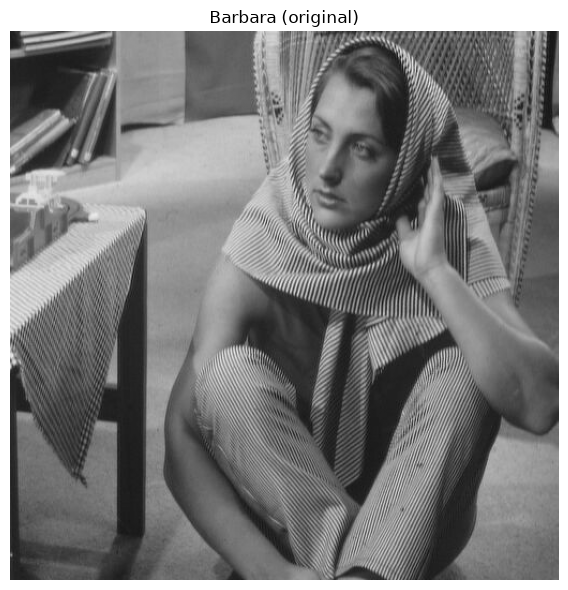

In [48]:
barbara = load_image('../data/barbara.jpg')
print(barbara.shape, barbara.min(), barbara.max())
show([barbara], ['Barbara (original)'], figsize=(6, 6))

### 3.1 Gradient filter

The x-derivative shows vertical edges, the y-derivative horizontal edges (grey = 0, the sign is the direction of the change)

The magnitude gives all edges.

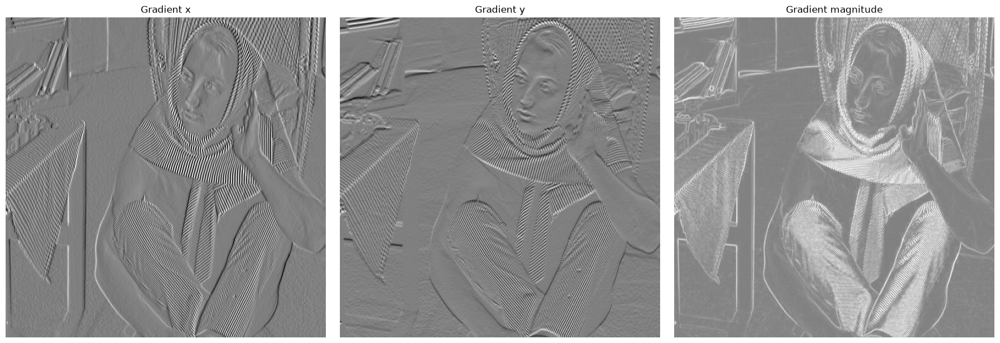

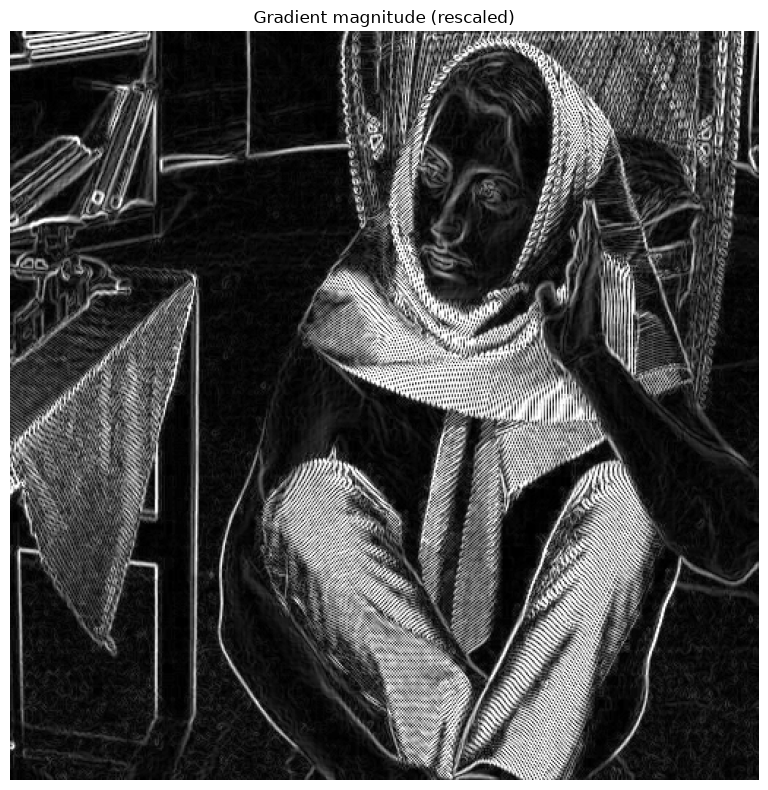

In [49]:
gx, gy, g = gradient_filter(barbara)

show(
    [gx, gy, g],
    ['Gradient x', 'Gradient y', 'Gradient magnitude'],
    vmin=-0.5, vmax=0.5)

show(
    [g],
    ['Gradient magnitude (rescaled)'],
    vmax=g.max()*0.5, figsize=(8, 8))

### 3.2 Sobel filter

Same edges, but cleaner and thicker: the smoothing along the edge direction removes part of the pixel-level noise and of the texture response.

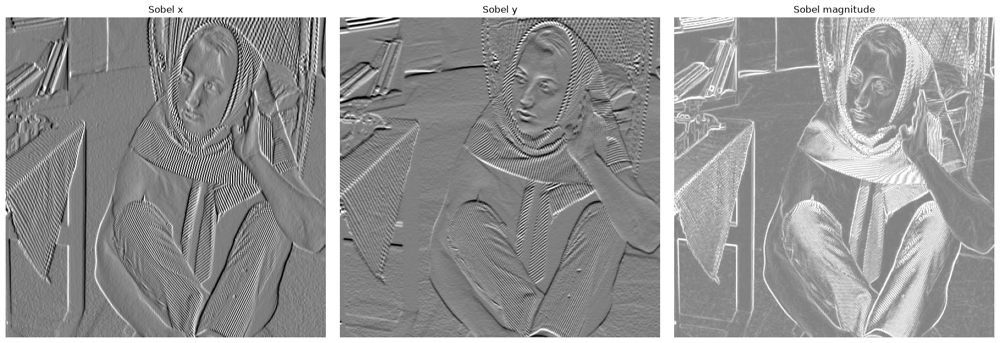

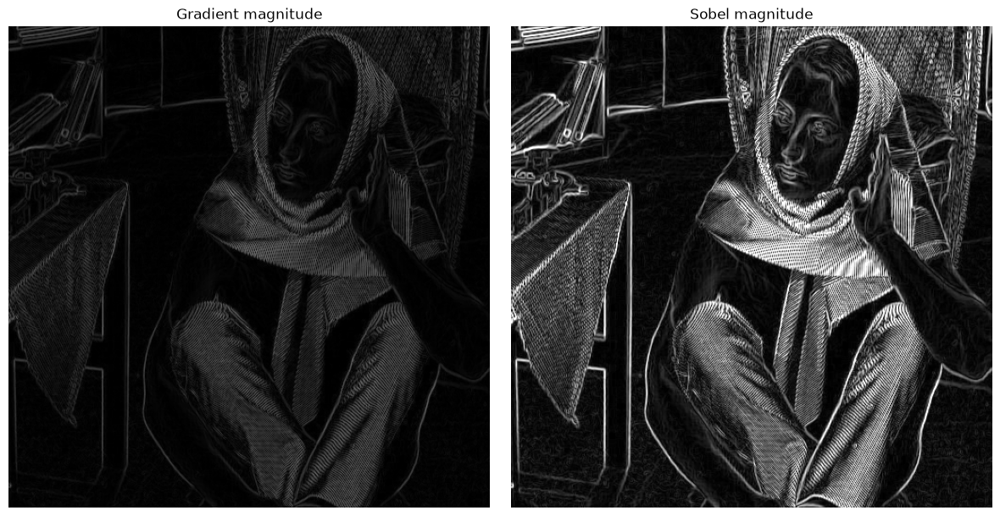

In [50]:
sx, sy, sm = sobel_filter(barbara)
show([sx, sy, sm],
    ['Sobel x', 'Sobel y', 'Sobel magnitude'],
    vmin=-1, vmax=1)
show([g, sm], ['Gradient magnitude', 'Sobel magnitude'], vmax=sm.max()*0.5)

### 3.3 Averaging filter

We try several sizes. The bigger the kernel, the stronger the blur: fine textures disappear first, then details, then edges.

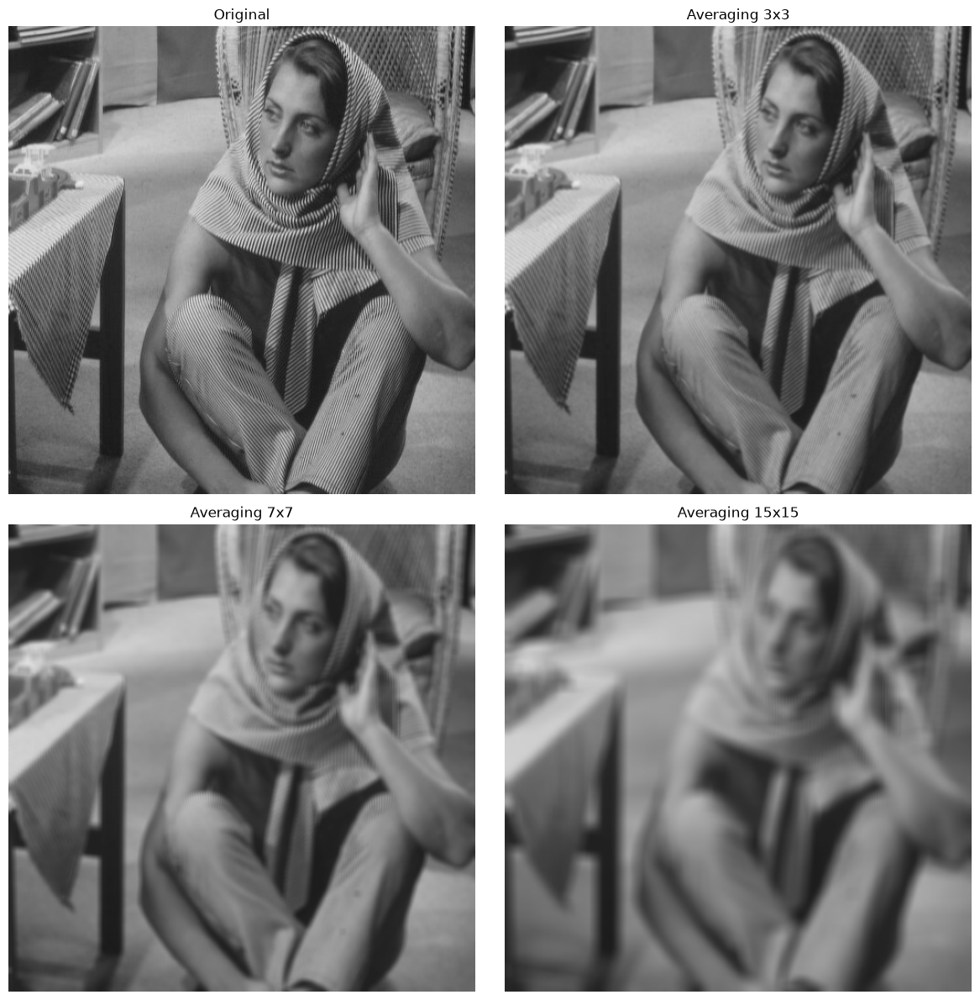

In [51]:
sizes = [3, 7, 15]
show([barbara] + [averaging_filter(barbara, k) for k in sizes],
     ['Original'] + [f'Averaging {k}x{k}' for k in sizes], cols=2)

### 3.4 Gaussian filter

Same idea with a Gaussian kernel; $\sigma$ sets the blur level.

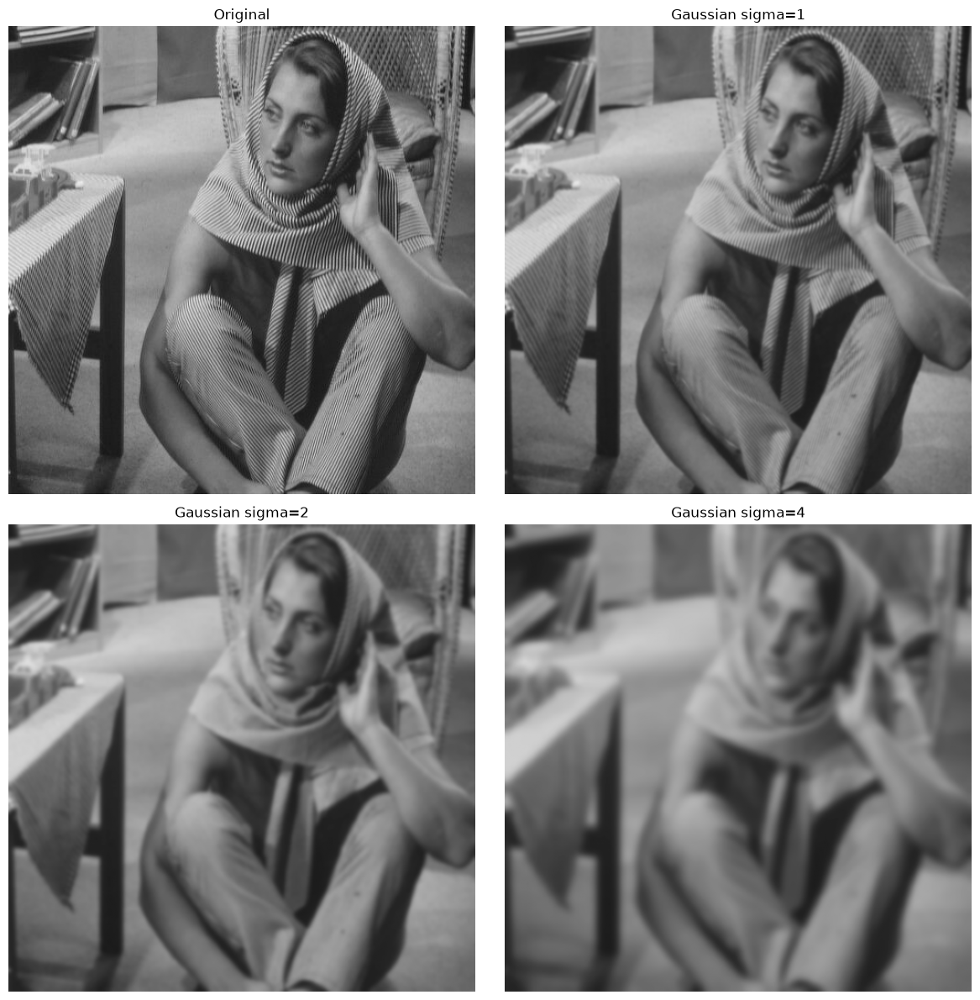

Gaussian kernel size for sigma=2: (13, 13)


In [52]:
sigmas = [1, 2, 4]
show([barbara] + [gaussian_filter_(barbara, s) for s in sigmas],
     ['Original'] + [f'Gaussian sigma={s}' for s in sigmas], cols=2)

k = gaussian_kernel(2.0)
print('Gaussian kernel size for sigma=2:', k.shape)

### 3.5 Averaging vs Gaussian

We compare them at a similar blur level, zoomed on a textured area of the image. The averaging filter keeps blocky artefacts and lets some periodic texture leak through; the Gaussian is smoother.

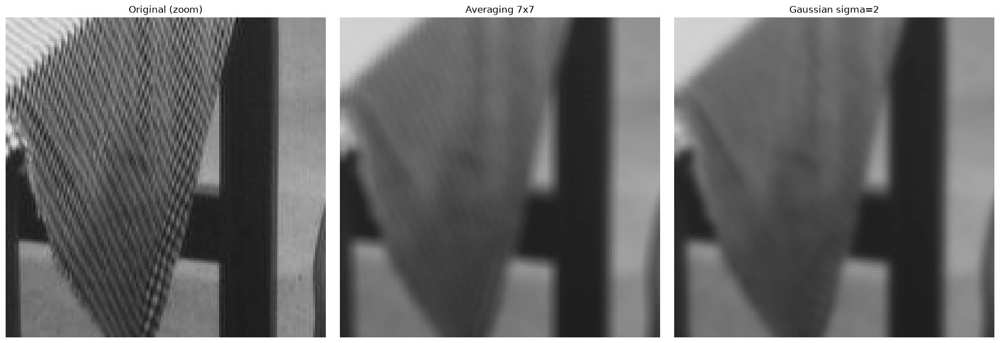

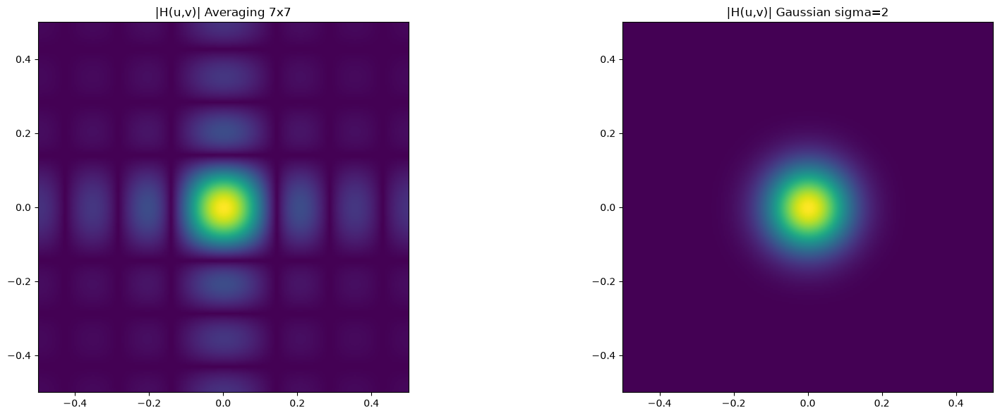

In [57]:
avg, gau = averaging_filter(barbara, 7), gaussian_filter_(barbara, 2)
crop = (slice(250, 400), slice(0, 150))
show([barbara[crop], avg[crop], gau[crop]], ['Original (zoom)', 'Averaging 7x7', 'Gaussian sigma=2'])

def freq_response_2d(kernel, n=256):
    return np.fft.fftshift(np.abs(np.fft.fft2(kernel, (n, n))))

fig, ax = plt.subplots(1, 2, figsize=(18, 6))
for a, kern, ti in zip(ax, [averaging_kernel(7), gaussian_kernel(2)],
                       ['Averaging 7x7', 'Gaussian sigma=2']):
    a.imshow(freq_response_2d(kern), cmap='viridis', extent=[-.5, .5, -.5, .5])
    a.set_title('|H(u,v)| ' + ti)
plt.tight_layout()
plt.show()

The averaging filter has side lobes (it lets some high frequencies through, sign-flipped), the Gaussian has none.

### 3.6 Noise: smoothing vs derivative filters

We add Gaussian noise and see how each filter behaves. Smoothing filters reduce it, while derivative filters amplify it (noise is a high-frequency signal), and Sobel less than the plain gradient.

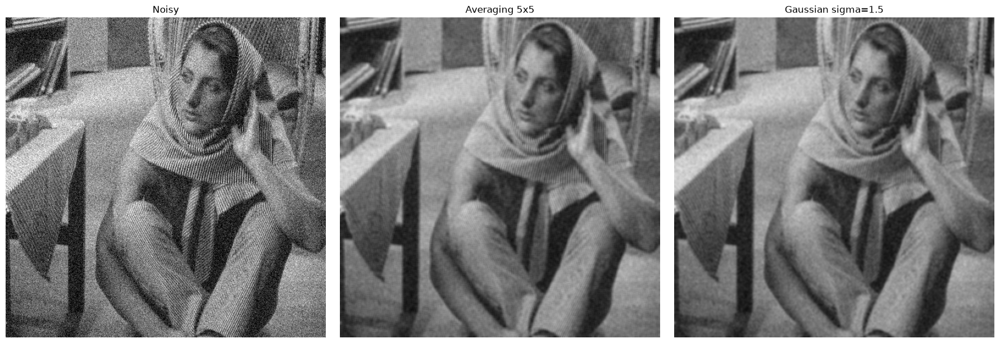

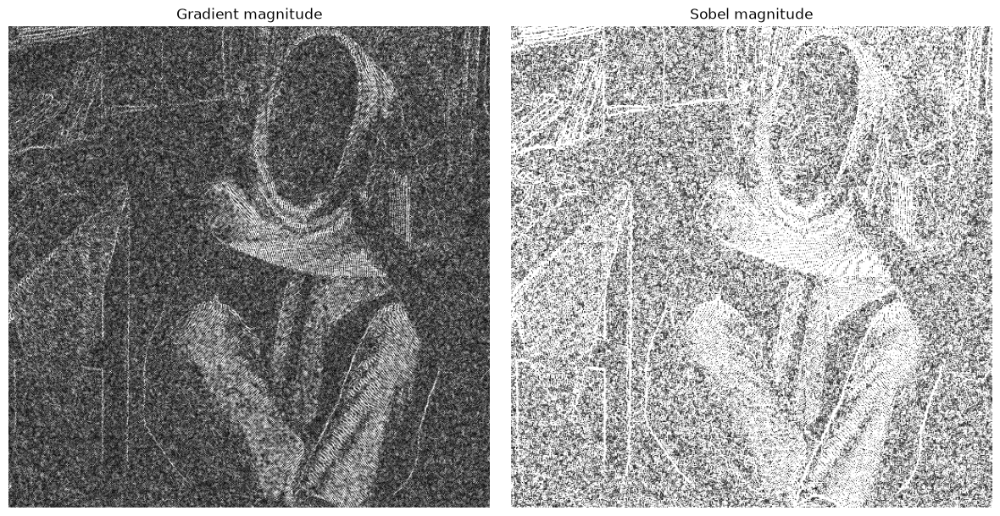

In [58]:
noisy = add_noise(barbara, sigma=0.1)
show([noisy, averaging_filter(noisy, 5), gaussian_filter_(noisy, 1.5)],
     ['Noisy', 'Averaging 5x5', 'Gaussian sigma=1.5'])

_, _, gm_n = gradient_filter(noisy)
_, _, sm_n = sobel_filter(noisy)
show([gm_n, sm_n], ['Gradient magnitude', 'Sobel magnitude'], vmax=0.6)

### Summary

| Filter | Type | Effect on Barbara | Noise |
|---|---|---|---|
| Gradient | high-pass | thin edges, also responds to fine textures | amplifies it a lot |
| Sobel | high-pass along one direction + smoothing in the other | clearer, thicker edges | amplifies it less |
| Averaging | low-pass | blur, blocky artefacts, textures vanish | reduces it |
| Gaussian | low-pass | smooth, natural blur controlled by $\sigma$ | reduces it, best trade-off |

Trade-off: smoothing removes noise but also edges; derivative filters find edges but amplify noise. A common practice is to smooth first (Gaussian) and then differentiate, which is roughly what Sobel does in one step.

## Bonus: colour Lenna

The functions work directly on colour images (`apply_filter` processes each channel). For smoothing we filter R, G, B separately. For edges, we compute the gradient on each channel and combine, plus a luminance version.

(512, 512, 3)


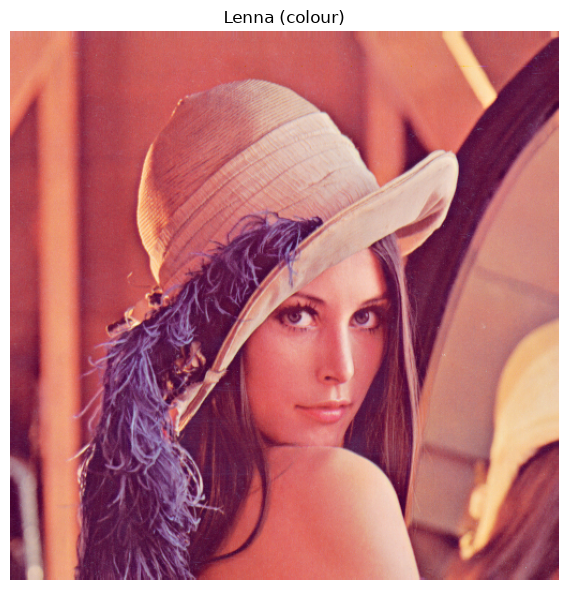

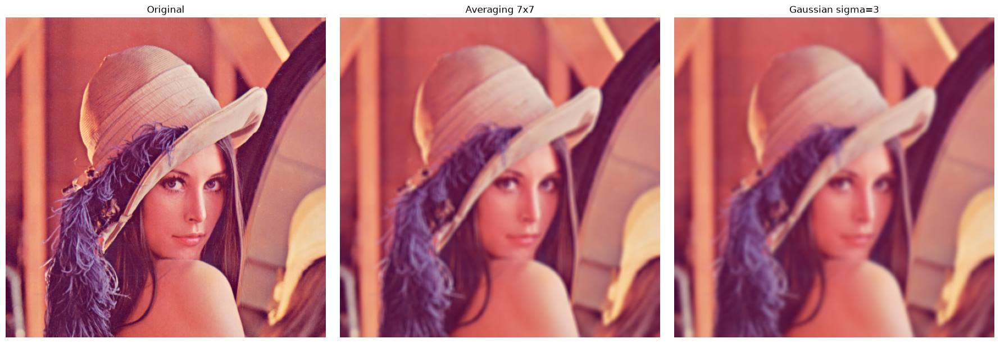

In [55]:
lenna = load_image('../data/Lenna_(test_image).png', gray=False)
print(lenna.shape)
show([lenna], ['Lenna (colour)'], figsize=(6, 6))

show([lenna, averaging_filter(lenna, 7), gaussian_filter_(lenna, 3)],
     ['Original', 'Averaging 7x7', 'Gaussian sigma=3'])

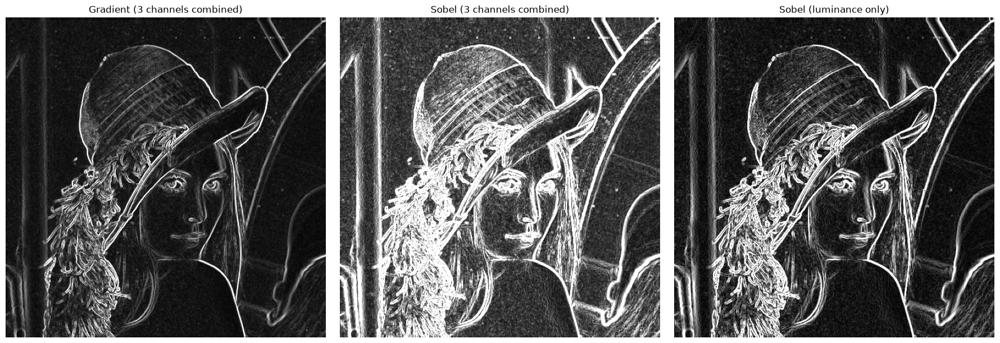

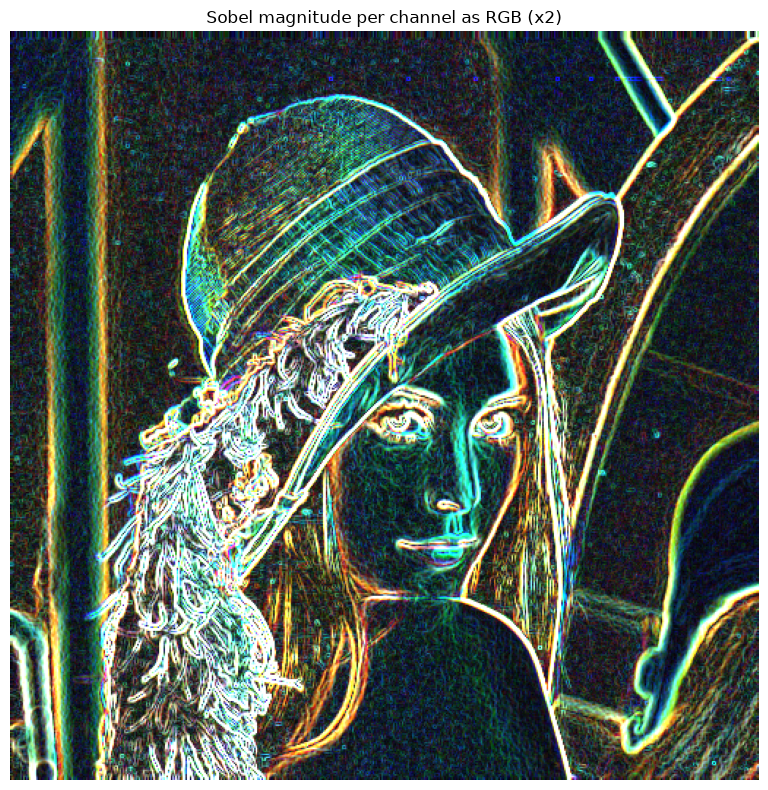

In [56]:
# Edges in colour: gradient of each channel, combined into one magnitude
def colour_edges(img, filt):
    mags = [filt(img[..., c])[2] for c in range(3)]
    return np.sqrt(sum(m**2 for m in mags)), np.stack(mags, axis=2)

grad_c, grad_rgb = colour_edges(lenna, gradient_filter)
sob_c, sob_rgb = colour_edges(lenna, sobel_filter)
lum = lenna.mean(axis=2)
sob_l = sobel_filter(lum)[2]

show([grad_c, sob_c, sob_l], ['Gradient (3 channels combined)', 'Sobel (3 channels combined)', 'Sobel (luminance only)'],
     vmax=0.6)
# per-channel magnitudes shown as an RGB image: coloured edges = edges present in only some channels
show([np.clip(sob_rgb * 2, 0, 1)], ['Sobel magnitude per channel as RGB (x2)'], figsize=(8, 8))

Combining the channels finds edges that appear in colour but not in brightness (a luminance-only filter misses them). In the per-channel RGB picture, a coloured edge means the boundary is strong in one colour channel only.